In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.precision", 8)

# Use pre-processed csv
data_table = "../data/preprocessed_data.csv"
df = pd.read_csv(data_table, delimiter=",")

In [21]:
import statsmodels.formula.api as smf

plot_df = df.copy()

plot_df["significant"] = (plot_df["P_value_num"] < 0.05).astype(int)

plot_df["TMA"] = (
    plot_df["TMA"]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace(["Nan", "Na", "N/a", ""], np.nan)
    .replace("Yes", "TMA")
    .replace("No", "Whole-slide")
)
print(plot_df["TMA"].value_counts(dropna=False))
plot_df = plot_df[plot_df["TMA"].isin(["TMA", "Whole-slide"])].copy()
# plot_df["TMA"] = plot_df["TMA"].fillna("Unknown")
plot_df["TMA"].value_counts(dropna=False)

TMA
Whole-slide    422
TMA            256
NaN             18
Name: count, dtype: int64


TMA
Whole-slide    422
TMA            256
Name: count, dtype: int64

<Axes: xlabel='Year', ylabel='Count'>

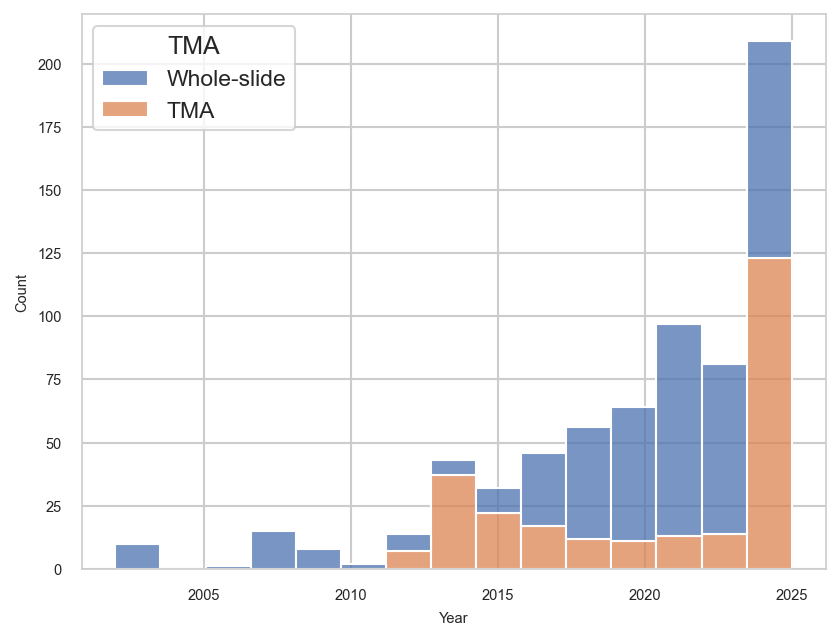

In [22]:
sns.histplot(data=plot_df, x="Year", hue="TMA", multiple="stack")

In [23]:
plot_df["sample_size"] = (
    plot_df["Sample size by the biomarker assessed"]
    .astype(str)
    .str.replace(",", "")
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

plot_df["sample_size"].describe()

count    678.00000000
mean     104.05014749
std       58.02788377
min       11.00000000
25%       60.00000000
50%       94.00000000
75%      151.00000000
max      367.00000000
Name: sample_size, dtype: float64

In [24]:
plot_df["log_sample_size"] = np.log(plot_df["sample_size"])
plot_df["Year_c"] = plot_df["Year"] - plot_df["Year"].mean()
plot_df["log_sample_size_c"] = (
    plot_df["log_sample_size"] - plot_df["log_sample_size"].mean()
)
model = smf.logit(
    "significant ~ C(TMA) + Year_c + log_sample_size_c",
    data=plot_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": plot_df["PubmedID"]}
)

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.540055
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            significant   No. Observations:                  678
Model:                          Logit   Df Residuals:                      674
Method:                           MLE   Df Model:                            3
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.02971
Time:                        09:42:30   Log-Likelihood:                -366.16
converged:                       True   LL-Null:                       -377.37
Covariance Type:              cluster   LLR p-value:                 5.322e-05
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.6602      0.260     -6.380      0.000      -2.170      -1.

In [25]:
plot_df["Year_c"] = plot_df["Year"] - plot_df["Year"].mean()
plot_df["log_sample_size_c"] = (
    plot_df["log_sample_size"] - plot_df["log_sample_size"].mean()
)
plot_df["Detection_simplified"] = (
    plot_df["Detection method"]
    .astype(str)
    .str.lower()
    .replace({
        "ihc": "IHC",
        "immunohistochemistry": "IHC",
        "sequencing": "Sequencing"
    })
)

# Everything that is not IHC → "Other"
plot_df.loc[
    ~plot_df["Detection_simplified"].isin(["IHC", "Sequencing"]),
    "Detection_simplified"
] = "Other"

model = smf.logit(
    "significant ~ C(TMA) + Year_c + log_sample_size_c + C(Detection_simplified, Treatment(reference='Other'))",
    data=plot_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": plot_df["PubmedID"]}
)

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.530873
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            significant   No. Observations:                  678
Model:                          Logit   Df Residuals:                      672
Method:                           MLE   Df Model:                            5
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.04621
Time:                        09:42:30   Log-Likelihood:                -359.93
converged:                       True   LL-Null:                       -377.37
Covariance Type:              cluster   LLR p-value:                 1.593e-06
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------

In [26]:
print(pd.crosstab(plot_df["Detection_simplified"], plot_df["significant"]))

significant             0    1
Detection_simplified          
IHC                   388  107
Other                  86   40
Sequencing             38   19


In [27]:
plot_df["Detection_simplified"].value_counts()

Detection_simplified
IHC           495
Other         126
Sequencing     57
Name: count, dtype: int64

In [28]:
plot_df["Year_c"] = plot_df["Year"] - plot_df["Year"].mean()
plot_df["log_sample_size_c"] = (
    plot_df["log_sample_size"] - plot_df["log_sample_size"].mean()
)
plot_df["Detection_simplified"] = (
    plot_df["Detection method"]
    .astype(str)
    .str.lower()
    .replace({
        "ihc": "IHC",
        "immunohistochemistry": "IHC",
        "sequencing": "Sequencing"
    })
)

# Everything that is not IHC → "Other"
plot_df.loc[
    ~plot_df["Detection_simplified"].isin(["IHC", "Sequencing"]),
    "Detection_simplified"
] = "Other"

model = smf.logit(
    "significant ~ C(TMA) + Year_c + log_sample_size_c + C(Detection_simplified, Treatment(reference='Other'))",
    data=plot_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": plot_df["PubmedID"]}
)

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.530873
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            significant   No. Observations:                  678
Model:                          Logit   Df Residuals:                      672
Method:                           MLE   Df Model:                            5
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.04621
Time:                        09:42:30   Log-Likelihood:                -359.93
converged:                       True   LL-Null:                       -377.37
Covariance Type:              cluster   LLR p-value:                 1.593e-06
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------

In [29]:
import itertools

# representative study sizes
sizes = {
    f"Small study (n≈{int(round(plot_df['sample_size'].quantile(0.25)))})": plot_df["sample_size"].quantile(0.25),
    f"Median study (n≈{int(round(plot_df['sample_size'].median()))})": plot_df["sample_size"].median(),
    f"Large study (n≈{int(round(plot_df['sample_size'].quantile(0.75)))})": plot_df["sample_size"].quantile(0.75),
}

years = np.linspace(plot_df["Year"].min(), plot_df["Year"].max(), 200)

det_ref = "Other"

pred_grid = pd.DataFrame(
    list(itertools.product(
        years,
        ["TMA", "Whole-slide"],
        sizes.keys()
    )),
    columns=["Year", "TMA", "size_group"]
)

pred_grid["Detection_simplified"] = det_ref
pred_grid["sample_size"] = pred_grid["size_group"].map(sizes)

# centered covariates must be centered in the same way as in the model
pred_grid["Year_c"] = pred_grid["Year"] - plot_df["Year"].mean()
pred_grid["log_sample_size_c"] = (
    np.log(pred_grid["sample_size"]) - plot_df["log_sample_size"].mean()
)

pred_grid["pred_prob"] = model.predict(pred_grid)

In [31]:
years = np.linspace(plot_df["Year"].min(), plot_df["Year"].max(), 200)

det_order = ["IHC", "Sequencing", "Other"]
method_order = ["TMA", "Whole-slide"]

pred_grid = pd.DataFrame(
    list(itertools.product(years, method_order, det_order)),
    columns=["Year", "TMA", "Detection_simplified"]
)

# use the same centering as in the fitted model
pred_grid["Year_c"] = pred_grid["Year"] - plot_df["Year"].mean()

# hold study size constant at a representative value
sample_ref = plot_df["sample_size"].median()
pred_grid["sample_size"] = sample_ref
pred_grid["log_sample_size"] = np.log(sample_ref)

# use this instead if your model contains log_sample_size_c
pred_grid["log_sample_size_c"] = np.log(sample_ref) - plot_df["log_sample_size"].mean()

pred_grid["pred_prob"] = model.predict(pred_grid)

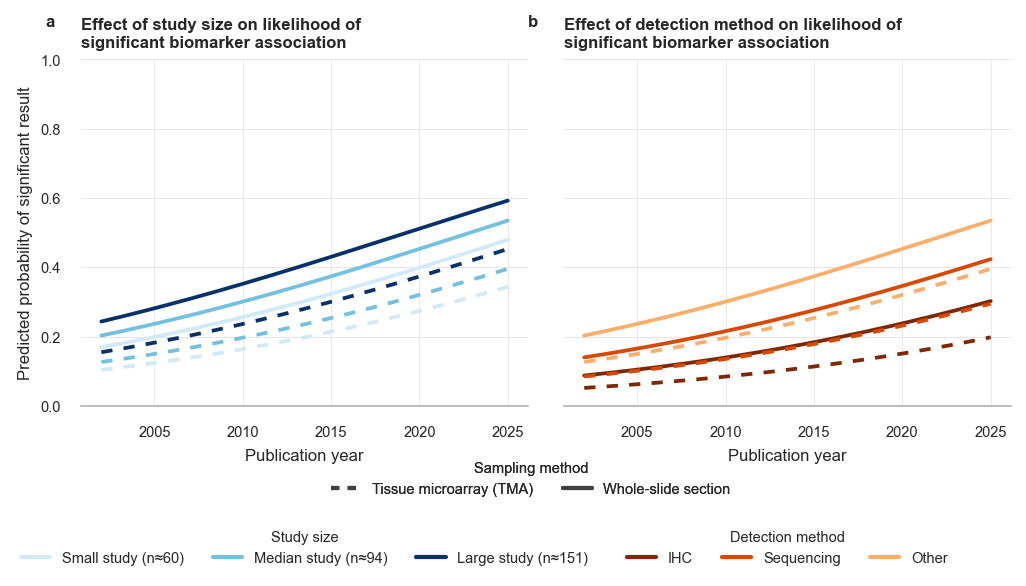

In [51]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Style
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth":  0.8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.labelsize":  7,
    "axes.titlesize":  8,
    "axes.titleweight":"bold",
    "figure.dpi":      150,
})

# Shared linestyle: TMA = dotted, Whole-slide = solid
dashes      = {"TMA": (2, 2), "Whole-slide": ""}
method_order = ["TMA", "Whole-slide"]

gray_vals = np.linspace(0.75, 0.2, 3)   # enough for up to 3 hue levels

# Pred grids
years = np.linspace(plot_df["Year"].min(), plot_df["Year"].max(), 200)
sample_ref = plot_df["sample_size"].median()

# Panel a: size_group
rows = []
for label, n in sizes.items():
    for year in years:
        for method in method_order:
            rows.append({
                "Year":               year,
                "TMA":                method,
                "size_group":         label,
                "Year_c":             year - plot_df["Year"].mean(),
                "log_sample_size_c":  np.log(n) - plot_df["log_sample_size"].mean(),
                "Detection_simplified": "Other",   # held at reference
            })
pred_grid_size = pd.DataFrame(rows)
pred_grid_size["pred_prob"] = model.predict(pred_grid_size)

# Panel b: detection method — hold log_sample_size_c constant
pred_grid_det = pd.DataFrame(
    list(itertools.product(years, method_order, det_order)),
    columns=["Year", "TMA", "Detection_simplified"]
)
pred_grid_det["Year_c"]              = pred_grid_det["Year"] - plot_df["Year"].mean()
pred_grid_det["sample_size"]         = sample_ref
pred_grid_det["log_sample_size"]     = np.log(sample_ref)
pred_grid_det["log_sample_size_c"]   = np.log(sample_ref) - plot_df["log_sample_size"].mean()
pred_grid_det["pred_prob"]           = model.predict(pred_grid_det)

# Panel a: Blues sequential
palette_size = {
    "Large study (n≈151)": "#08306B",   # darkest
    "Median study (n≈94)": "#74C0E0",
    "Small study (n≈60)":  "#D0EAF8",   # lightest — readable on white bg
}

# Panel b: Oranges sequential
palette_det = {
    "IHC":        "#7F2704",   # dark burnt orange
    "Sequencing": "#D94801",   # mid vermillion
    "Other":      "#FDAE6B",   # light peach
}

# ── Linestyle: only encodes sampling method (not category) ────────────────
dashes = {"TMA": (3, 3), "Whole-slide": ""}   # dotted vs solid — unchanged


# Figure: 1 row, 2 panels
fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(8, 3),
    sharey=True,
    gridspec_kw={"wspace": 0.08}
)

panel_configs = [
    dict(
        ax        = axes[0],
        data      = pred_grid_size,
        hue       = "size_group",
        hue_order = size_labels,
        palette   = palette_size,
        leg_title = "Study size",
        title     = "Study size",
        letter    = "a",
    ),
    dict(
        ax        = axes[1],
        data      = pred_grid_det,
        hue       = "Detection_simplified",
        hue_order = det_order,
        palette   = palette_det,
        leg_title = "Detection method",
        title     = "Detection method",
        letter    = "b",
    ),
]

for cfg in panel_configs:
    ax = cfg["ax"]

    sns.lineplot(
        data        = cfg["data"],
        x           = "Year",
        y           = "pred_prob",
        hue         = cfg["hue"],
        hue_order   = cfg["hue_order"],
        style       = "TMA",
        style_order = method_order,
        dashes      = dashes,
        palette     = cfg["palette"],
        linewidth   = 1.8,
        errorbar    = None,
        ax          = ax,
    )

    if ax.legend_ is not None:
        ax.legend_.remove()

    # Hue legend (right of each panel, middle)
    hue_handles = [
        Line2D([0], [0], color=cfg["palette"][lbl], lw=2, label=lbl)
        for lbl in cfg["hue_order"]
    ]
    leg1 = ax.legend(
        handles         = hue_handles,
        title           = cfg["leg_title"],
        frameon         = False,
        bbox_to_anchor  = (1.02, 0.5),
        loc             = "center left",
        fontsize        = 7,
        title_fontsize  = 7,
    )

    # Sampling method legend (right of each panel, top) — only label once per panel
    method_handles = [
        Line2D([0], [0], color="0.25", lw=2, linestyle=(0,(2,2)), label="Tissue microarray (TMA)"),
        Line2D([0], [0], color="0.25", lw=2, linestyle="-",       label="Whole-slide section"),
    ]

    # Inside the loop, replace both legend blocks with nothing (just remove the auto legend):
    if ax.legend_ is not None:
        ax.legend_.remove()

    # Panel label
    ax.text(-0.08, 1.13, cfg["letter"], transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

    ax.set_ylim(0, 1)
    ax.set_xlabel("Publication year", fontsize=8)
    ax.set_title(
        f"Effect of {cfg['title'].lower()} on likelihood of\nsignificant biomarker association",
        loc="left", pad=6, fontsize=8
    )

    ax.grid(axis="y", color="0.9",  linewidth=0.5)
    ax.grid(axis="x", color="0.92", linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("0.7")
    ax.tick_params(axis="both", labelsize=7)

axes[0].set_ylabel("Predicted probability of significant result", fontsize=8)
axes[1].set_ylabel("")   # shared axis, no duplicate label

# Legends below panels
method_handles = [
    Line2D([0], [0], color="0.25", lw=2, linestyle=(0,(2,2)), label="Tissue microarray (TMA)"),
    Line2D([0], [0], color="0.25", lw=2, linestyle="-",       label="Whole-slide section"),
]

size_handles = [
    Line2D([0], [0], color=panel_configs[0]["palette"][lbl], lw=2, label=lbl)
    for lbl in size_labels
]

det_handles = [
    Line2D([0], [0], color=panel_configs[1]["palette"][lbl], lw=2, label=lbl)
    for lbl in det_order
]

# Sampling method — centred below both panels
leg_method = fig.legend(
    handles        = method_handles,
    title          = "Sampling method",
    frameon        = False,
    loc            = "lower center",
    bbox_to_anchor = (0.5, -0.12),
    ncol           = 2,
    fontsize       = 7,
    title_fontsize = 7,
)

# Study size — below panel a
leg_size = axes[0].legend(
    handles        = size_handles,
    title          = "Study size",
    frameon        = False,
    loc            = "upper center",
    bbox_to_anchor = (0.5, -0.32),
    ncol           = 3,
    fontsize       = 7,
    title_fontsize = 7,
)

# Detection method — below panel b
leg_det = axes[1].legend(
    handles        = det_handles,
    title          = "Detection method",
    frameon        = False,
    loc            = "upper center",
    bbox_to_anchor = (0.5, -0.32),
    ncol           = 3,
    fontsize       = 7,
    title_fontsize = 7,
)

fig.add_artist(leg_method)

plt.savefig(
    "figures/tma_vs_whole-slide_combined.pdf",
    bbox_inches="tight",
    facecolor="white",
)
plt.savefig(
    "figures/tma_vs_whole-slide_combined.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()